# Data Analyst Professional Practical Exam Submission

**You can use any tool that you want to do your analysis and create visualizations. Use this template to write up your summary for submission.**

You can use any markdown formatting you wish. If you are not familiar with Markdown, read the [Markdown Guide](https://s3.amazonaws.com/talent-assets.datacamp.com/Markdown+Guide.pdf) before you start.

## 📝 Task List

Your written report should include written text summaries and graphics of the following:
- Data validation:   
  - Describe validation and cleaning steps for every column in the data 
- Exploratory Analysis:  
  - Include two different graphics showing single variables only to demonstrate the characteristics of data  
  - Include at least one graphic showing two or more variables to represent the relationship between features
  - Describe your findings
- Definition of a metric for the business to monitor  
  - How should the business use the metric to monitor the business problem
  - Can you estimate initial value(s) for the metric based on the current data
- Final summary including recommendations that the business should undertake

*Start writing report here..*

## ✅ When you have finished...
-  Publish your Workspace using the option on the left
-  Check the published version of your report:
	-  Can you see everything you want us to grade?
    -  Are all the graphics visible?
-  Review the grading rubric. Have you included everything that will be graded?
-  Head back to the [Certification Dashboard](https://app.datacamp.com/certification) to submit your practical exam report and record your presentation

# Introduction

A new line of office stationery were launched 6 weeks ago. In focus to optimize the sales and revenues for our company three sales strategies were implemented: Email, Call and Email + Call. In this report we analyze the effectiviness of these strategies and insights which may be the best strategy in the future. 

The following report is divided in: 
- Data Validation and cleaning process of the dataset.
- Exploratory Analysis of the different variables, their differences and their relationships.
- Definition of a metric for our buissnes to monitor and assess the efectiviness in the future.
- Final summary and recomendations

In [2]:
# Libraries used in this report
library(tidyverse)
if (!require("ggsignif")) install.packages("ggsignif")
library(ggsignif)
if (!require("car")) install.packages("car")
library(car)
if (!require("scales")) install.packages("scales")
library(scales)


# Data used in this report
data <- read.csv("product_sales.csv")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: ggsignif

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘ggsignif’”


# Downloading packages -------------------------------------------------------
- Downloading ggsignif from CRAN ...            OK [587.7 Kb in 0.39s]
Successfully downloaded 1 package in 1.3 seconds.

The following package(s) will be installed:
- ggsignif [0.6.4]
These packages will be installed into "~/renv/library/R-4.2/x86_64-pc-linux-gnu".

# Installing packages --------------------------------------------------------
- Installing ggsignif ...                       OK [installed binary and cached in 0.62s]


Loading required package: car

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some


Loading required package: scales


Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




In [3]:
#First visualization of the data
str(data)

'data.frame':	15000 obs. of  8 variables:
 $ week             : int  2 6 5 4 3 6 4 1 5 5 ...
 $ sales_method     : chr  "Email" "Email + Call" "Call" "Email" ...
 $ customer_id      : chr  "2e72d641-95ac-497b-bbf8-4861764a7097" "3998a98d-70f5-44f7-942e-789bb8ad2fe7" "d1de9884-8059-4065-b10f-86eef57e4a44" "78aa75a4-ffeb-4817-b1d0-2f030783c5d7" ...
 $ nb_sold          : int  10 15 11 11 9 13 11 10 11 11 ...
 $ revenue          : num  NA 225.5 52.5 NA 90.5 ...
 $ years_as_customer: int  0 1 6 3 0 10 9 1 10 7 ...
 $ nb_site_visits   : int  24 28 26 25 28 24 28 22 31 23 ...
 $ state            : chr  "Arizona" "Kansas" "Wisconsin" "Indiana" ...


# Data Validation 

The data recieved consist in 8 variables with 15,000 observation or registers. The variables are the following:


- **week**: Week sale was made, counted as weeks since product launch, stored as a integer, but acts as a category nominal level. From 1 to 6. No empty values were identified in this column. No modifications were necessary

- **sales_method**: This column is stored as a caracter, so an adjustment was employed to store as a factor with three nominal categories: "Email", "Call", "Email + Call". In the validation process were identified some misspeled words such as "em + call" and "email", so an unification were employed to fit this categories in their correct factor. No empty values were identified in this column. A total of 3 groups and 15,000 regisers in total were confirmed.

- **customer_id**: This is unique for each customer. No duplicates or missing values were identified. No changes were necessary.

- **nb_sold**: Number of units sold. The number of products needs to be a integer. No double (continuous) numbers or empty values were identified. No changes were necessary in this column.

- **revenue**: Revenue from the sales, rounded to 2 decimal places. 1074 empty values were identified as NA, and replaced with the mean of the non-na values. No other changes on this column were necessary.

- **year_as_customer**: Number of years that a customer has been buying from our stores. As the maximum value coherent in this case is 41 (accordingly with the foundation year 1984), two abnormal outliers were identified and replaced with the maximum value possible 41. No missing values were identified and no other changes were necessary. 
 
- **nb_site_visits**: The number of visits in our website in the last 6 months that a customer has made. No missing values were identified and no changes where necessary. 

- **state**: States of the United States as a full name. This column is stored as a caracter, so an adjustment was employed to store as a factor with 50 different countries identified.


In [4]:
# Data Validation: Used data_val (as data_validated)
data_val <- data %>%
  mutate(
    sales_method = case_when(
      sales_method == "em + call" ~ "Email + Call",
      sales_method == "email"    ~ "Email",
      TRUE ~ sales_method
    ) %>%
    factor(levels = c("Email", "Call", "Email + Call")), 
    state = factor(state),
    revenue = replace_na(revenue, mean(revenue, na.rm = TRUE)) 
  ) %>%
  mutate(years_as_customer = ifelse(years_as_customer > 41, 41, years_as_customer)) 

summary(data_val)

      week             sales_method  customer_id           nb_sold     
 Min.   :1.000   Email       :7466   Length:15000       Min.   : 7.00  
 1st Qu.:2.000   Call        :4962   Class :character   1st Qu.: 9.00  
 Median :3.000   Email + Call:2572   Mode  :character   Median :10.00  
 Mean   :3.098                                          Mean   :10.08  
 3rd Qu.:5.000                                          3rd Qu.:11.00  
 Max.   :6.000                                          Max.   :16.00  
                                                                       
    revenue       years_as_customer nb_site_visits           state     
 Min.   : 32.54   Min.   : 0.000    Min.   :12.00   California  :1872  
 1st Qu.: 53.04   1st Qu.: 1.000    1st Qu.:23.00   Texas       :1187  
 Median : 91.86   Median : 3.000    Median :25.00   New York    : 965  
 Mean   : 93.93   Mean   : 4.964    Mean   :24.99   Florida     : 904  
 3rd Qu.:106.07   3rd Qu.: 7.000    3rd Qu.:27.00   Illinois    

In [5]:
# Confirmation of data validation

# Confirmation of the three cathegories in sales_method
sum(table(data_val$sales_method))
table(data_val$sales_method)
nlevels(data_val$sales_method)

# Confirmation of 15,000 different values and no duplicated data in customer_id 
nlevels(as.factor(data_val$customer_id))
sum(duplicated(data_val$customer_id))

# Confirmation of 50 different states in the registration in state
data_val$state <- as.factor(data_val$state)
nlevels(data_val$state)

[1] 15000


       Email         Call Email + Call 
        7466         4962         2572 

[1] 3

[1] 15000

[1] 0

[1] 50

# Exploratory Analysis

In [6]:
# Summary table of the nummerical categories
data_val %>%
group_by(sales_method) %>%
summarize(n_customers = n(), 
		 rev_mean = mean(revenue), 
		 rev_median = median(revenue), 
		 rev_sd = sd(revenue), 
		 nb_sold_mean = mean(nb_sold), 
		 nb_sold_median = median(nb_sold), 
		 nb_sold_sd = sd(nb_sold),
		 years_mean = mean(years_as_customer), 
		 years_median = median(years_as_customer), 
		 years_sd = sd(years_as_customer),
		 visit_mean = mean(nb_site_visits), 
		 visit_median = median(nb_site_visits), 
		 visit_sd = sd(nb_site_visits))

sales_method,n_customers,rev_mean,rev_median,rev_sd,nb_sold_mean,nb_sold_median,nb_sold_sd,years_mean,years_median,years_sd,visit_mean,visit_median,visit_sd
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Email,7466,96.89505,94.275,10.82613,9.729306,10,1.179299,4.980847,3,5.050426,24.75435,25,3.281552
Call,4962,49.28773,49.935,12.12050,9.509674,10,1.733856,5.175534,4,5.114376,24.42382,24,3.599864
Email + Call,2572,171.47744,182.135,40.93171,12.225505,12,1.931459,4.507387,3,4.760987,26.77138,27,3.357916


# 1. Number of Customers for each Sales Method

A total of 15,000 customers were included in the analysis, these customers were assigned into one of the three sales strategies. The method with most customers was "Email" with 7,466 customers, followed by "Call" with 4962 customers and lastly "Email + Call" with 2572 customers. 

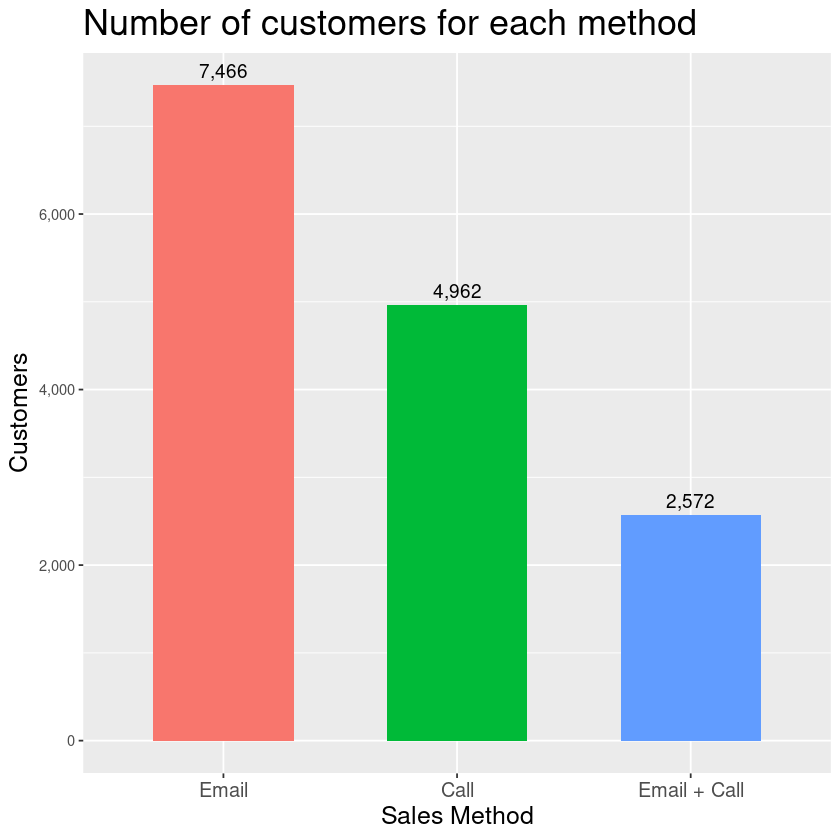

In [7]:
# Data manipulation and graph to obtain the number of customers per method
count <- data_val %>%
  count(sales_method) %>%
  mutate(n_formatted = comma(n))

ggplot(count, aes(x = sales_method, y = n, fill = sales_method)) +
  geom_bar(stat = "identity", width = 0.6) +
  geom_text(aes(label = n_formatted), vjust = -0.5, size = 4) +
  labs(title = "Number of customers for each method", x = "Sales Method", y = "Customers") +
  scale_y_continuous(labels = label_comma()) +
  theme(legend.position = "none", axis.text.x = element_text(size = 12), axis.title = element_text(size = 15), title = element_text(size = 18))

# 2. Spread of Revenue

## 2.1. Overal Spread of Revenue

The overall revenue indicates that most of the customers generated a revenue of 100 USD, while the overall revenue is skewed to the left indicates that the customers generated a revenue of less 100 USD, and some minority generated a revenue of a maximum of approximate 240 USD. 

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


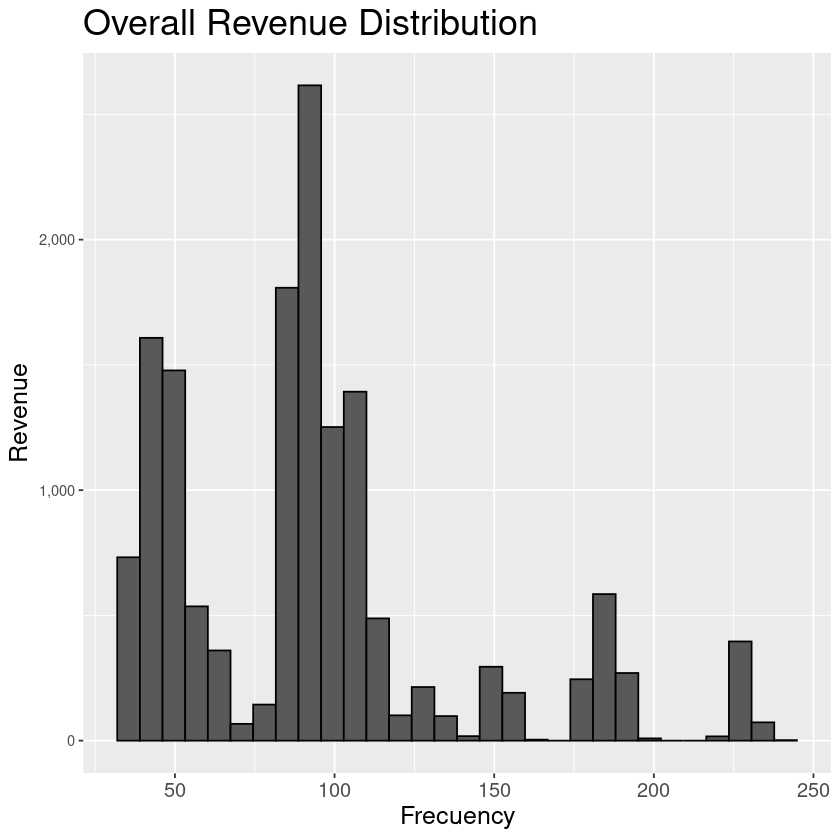

In [8]:
# Histogram of the overall revenue spread
ggplot(data_val, aes(x = revenue)) + 
geom_histogram(color = "black") + 
labs(title = "Overall Revenue Distribution", x = "Frecuency", y = "Revenue") +
  scale_y_continuous(labels = label_comma()) +
theme(axis.text.x = element_text( size = 12), axis.title = element_text(size = 15), title = element_text(size = 18))

## 2.2 Spread of revenue for each sales method

To evaluate the spread of revenue for each method, a boxplot was created. To evaluate if the overall revenue grouped by each strategy a statistical test was used. To confirm the election for the statistical test a QQ plot and Levene test was employed, defining the election for Kruskal Wallis test, denoting that there is statistical difference between the customer revenue by each group and between all of them. 

This means, the customers in the Email + Call group tended to generated more revenue, followed by the Email group, and lastly the customers in the Call group. 

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,2826.116,0
,14997,NA,NA


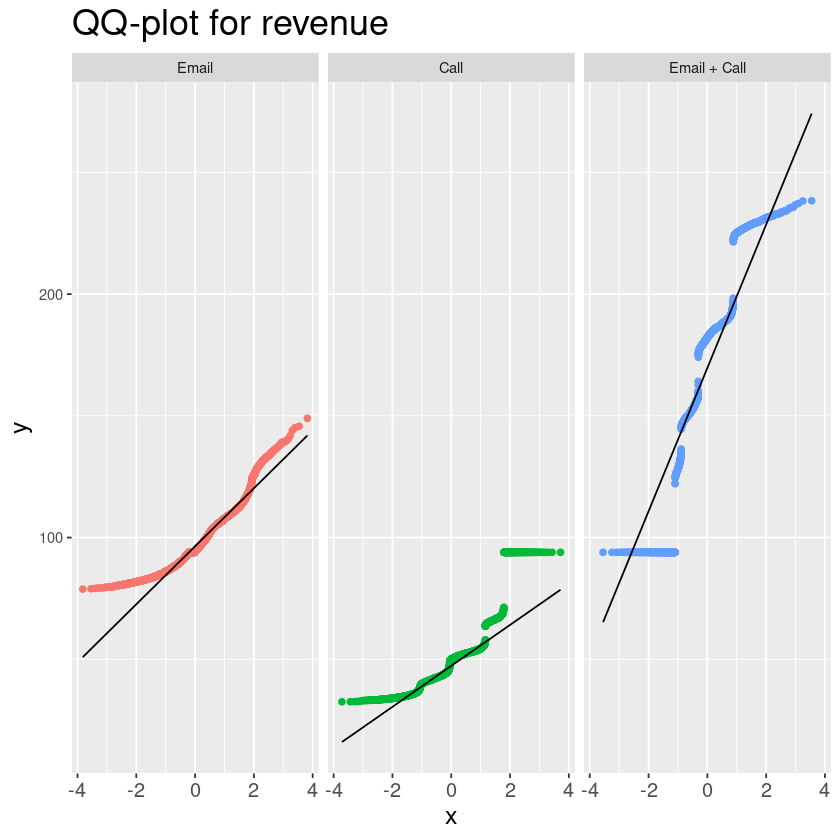

In [9]:
# Assumption analysis
data_val %>%
ggplot(aes(sample = revenue)) +
  stat_qq(aes(color = sales_method)) +
  stat_qq_line() +
  labs(title = "QQ-plot for revenue") + 
  facet_wrap(~sales_method) + 
  theme(axis.text.x = element_text( size = 12), axis.title = element_text(size = 15), title = element_text(size = 18), legend.position = "none")

leveneTest(revenue ~ sales_method, data = data_val)



	Kruskal-Wallis rank sum test

data:  revenue by sales_method
Kruskal-Wallis chi-squared = 11375, df = 2, p-value < 2.2e-16



	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  data_val$revenue and data_val$sales_method 

             Email  Call  
Call         <2e-16 -     
Email + Call <2e-16 <2e-16

P value adjustment method: bonferroni 

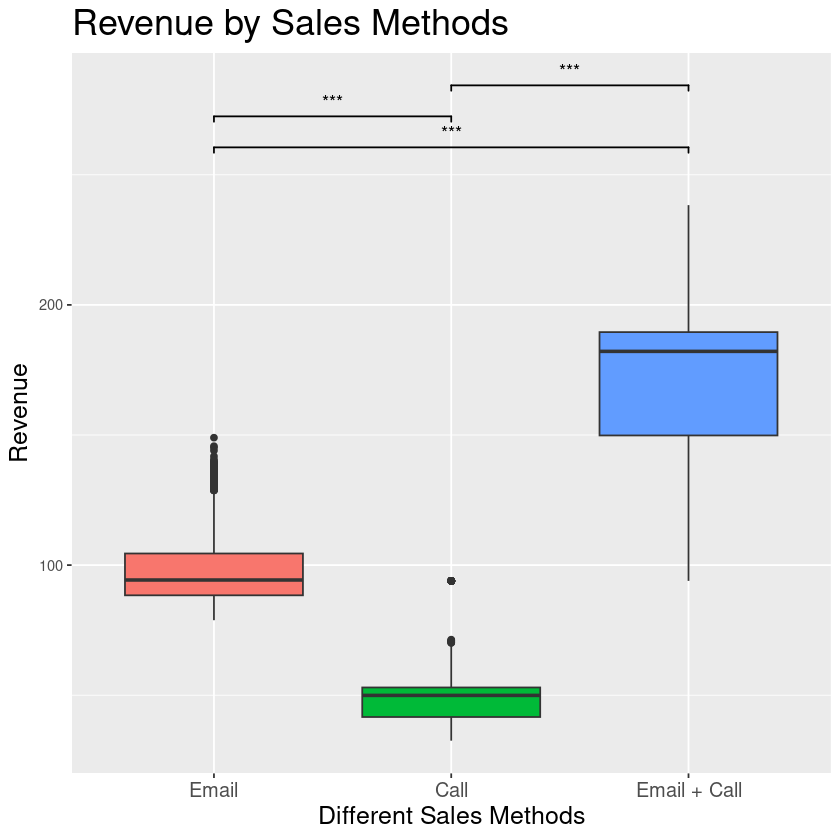

In [10]:
# Revenue by Sales Method with significance symbols

# Comparasions list 
comparisons <- list(
  c("Email", "Email + Call"),
  c("Call", "Email"),
  c("Email + Call", "Call"))

#Kruskal Wallis test
kw_revenue <- kruskal.test(revenue ~ sales_method, data = data_val)
kw_revenue

#Wilcoxon posthoc test with Bonferroni p-adjustment
posthoc_revenue <- pairwise.wilcox.test(x = data_val$revenue,
                g = data_val$sales_method,
                p.adjust.method = "bonferroni")
posthoc_revenue

#Position of statistical symbols
max_rev <- max(data_val$revenue, na.rm = TRUE)
y_positions <- seq(from = max_rev * 1.05,
                   by   = max_rev * 0.05,
                   length.out = length(comparisons))

#Conditioning for statistical symbols
pvals <- na.omit(as.vector(posthoc_revenue$p.value))
annotations <- ifelse(pvals < 0.001, "***",
               ifelse(pvals < 0.01, "**",
               ifelse(pvals < 0.05, "*", "ns")))

#Boxplot of revenue by sales methods 
ggplot(data_val, aes(x = sales_method, y = revenue, fill = sales_method)) +
  geom_boxplot() +
  geom_signif(comparisons = comparisons,
              annotations = annotations,
              y_position = y_positions,
              tip_length = 0.01) + 
 labs(title = "Revenue by Sales Methods", x = "Different Sales Methods", y = "Revenue") + 
theme(legend.title = element_blank(), legend.position = "none", axis.text.x = element_text( size = 12), axis.title = element_text(size = 15), title = element_text(size = 18))

# 3. Differences in Revenue over Time for each sale strategy

The total revenue of the six weeks were $1,409,024.14. Of this total, 51.34% were generated by the Email group, followed by the Email + Call group with 31.31% and lastly the Call group with 17.35%.
Then I realize an analyze of the revenue into the six weeks. The findings are crucial to define which stratehy was more successful: 
- The Email method in the first week generated the highest revenue, with 84% of the revenue of that week. This indicate that at first week this method is the more efficient,  but, after that, the Email method decreased substanciantly and in the sixth week the revenue was 1/10 of the first.
- The Call method were constant and practically unifform with a discreate increasing just as the end of the fifth week, at sixth week the revenue decreased. This indicate that this method is constant the revenue is minnimal and over time tends to decrease.
- The Email + Call Method started as the lowest revenue at the first week with just 6.2% of the first week revenue. However the tendency were a substancial increase in the revenue with a maximum point at the fifth week with 6.5 times the revenue of the first week of this method. At the last week the revenue presented a discrete decrease.

This analysis deluced that the Email + Call method is the most promising method as it takes 1/3 of the time call, and just more work for the email. The email method starts with the highest revenue, but declines just as the second week ends. And the Call method is constant but with no significant revenue. Posterior analysis are generated to clarify the most efficient method. 

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“A numeric `legend.position` argument in `theme()` was deprecated in ggplot2
3.5.0.
ℹ Please use the `legend.position.inside` argument of `theme()` instead.”


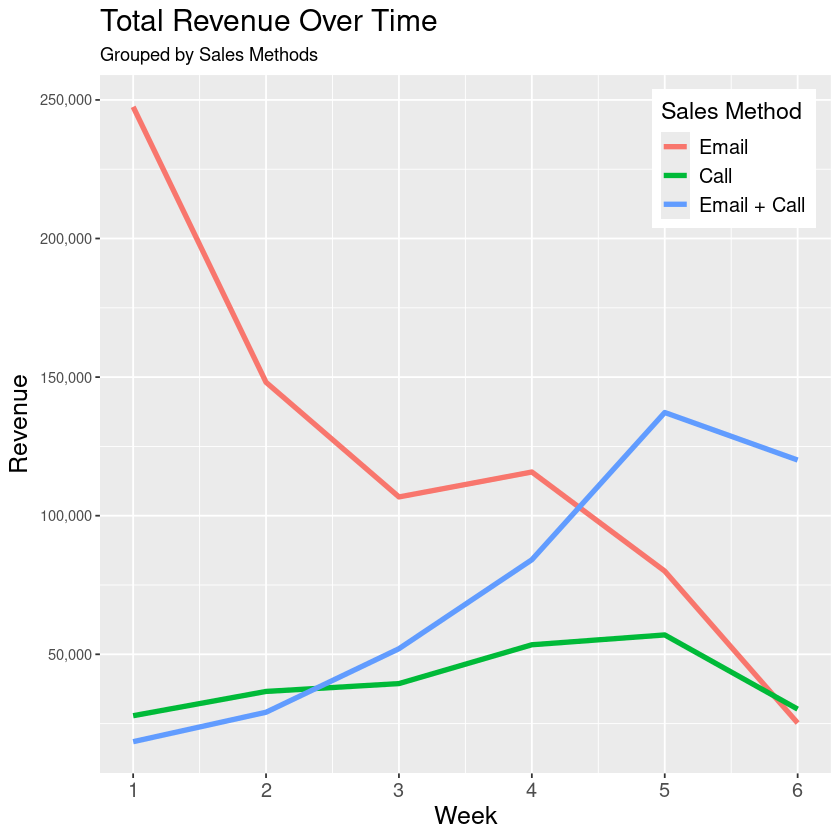

In [11]:
#Total revenue in weeks by sales method
data_val %>%
  group_by(week, sales_method) %>%
  summarize(revenue = sum(revenue), .groups = "drop") %>%
  ggplot(aes(x = week, y = revenue, color = sales_method)) +
  geom_line(size = 1.5) + 
  scale_y_continuous(labels = label_comma()) +
  labs(title = "Total Revenue Over Time", subtitle = "Grouped by Sales Methods", x = "Week", y = "Revenue", color = "Sales Method") + 
  scale_x_continuous(breaks = c(1:6)) +
  theme(plot.title = element_text(size = 18), legend.position = c(0.98, 0.98), legend.justification = c(1, 1),legend.title = element_text(size = 14), legend.text  = element_text(size = 12), axis.text.x = element_text( size = 12), axis.title = element_text(size = 15)) 

In [12]:
#Revenue over time and proportion
revenue_time <- data_val %>% 
  group_by(week, sales_method) %>%
  summarize(sum = sum(revenue), .groups = "drop") %>% 
  pivot_wider(names_from = sales_method, values_from = sum) %>%
  mutate(Total = rowSums(select(., -week)))

revenue_total <- revenue_time %>%
summarize(week = NA,
	     Email = sum(Email), 
		 Call = sum(Call), 
		 `Email + Call` = sum(`Email + Call`), 
		 Total = sum(Total)) 

revenue_summ <- bind_rows(revenue_time, revenue_total)
revenue_summ

revenue_summ_prop <- revenue_summ %>%
  mutate(across(c(Email, Call, `Email + Call`), ~ .x / Total)) %>%
  mutate(Email = Email * 100, 
		 Call = Call * 100, 
		 `Email + Call` = `Email + Call` * 100,
		 Total = 100)

revenue_summ_prop

week,Email,Call,Email + Call,Total
<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,247519.25,27850.01,18482.22,293851.5
2,148130.48,36610.07,29100.34,213840.9
3,106776.61,39441.06,52024.86,198242.5
4,115772.84,53445.32,84120.17,253338.3
5,80009.55,56993.70,137236.50,274239.7
6,25209.71,30225.55,120075.89,175511.2
NA,723418.44,244565.71,441039.98,1409024.1


week,Email,Call,Email + Call,Total
<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,84.23277,9.47758,6.289648,100
2,69.27135,17.12024,13.608409,100
3,53.86161,19.89536,26.243038,100
4,45.69890,21.09642,33.204674,100
5,29.17504,20.78244,50.042527,100
6,14.36359,17.22144,68.414963,100
NA,51.34181,17.35710,31.301095,100


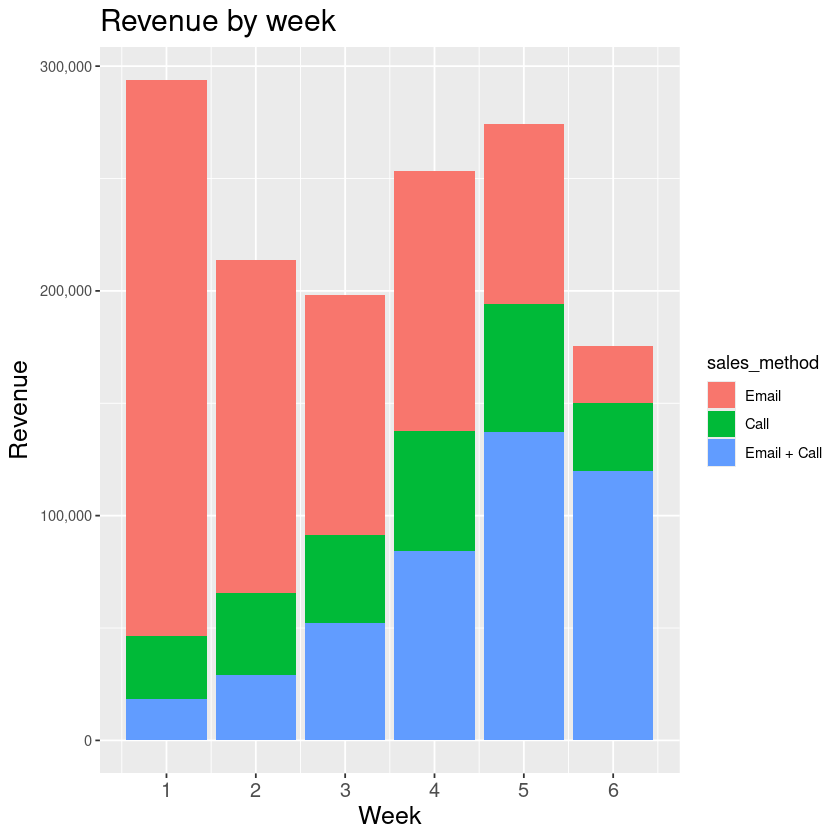

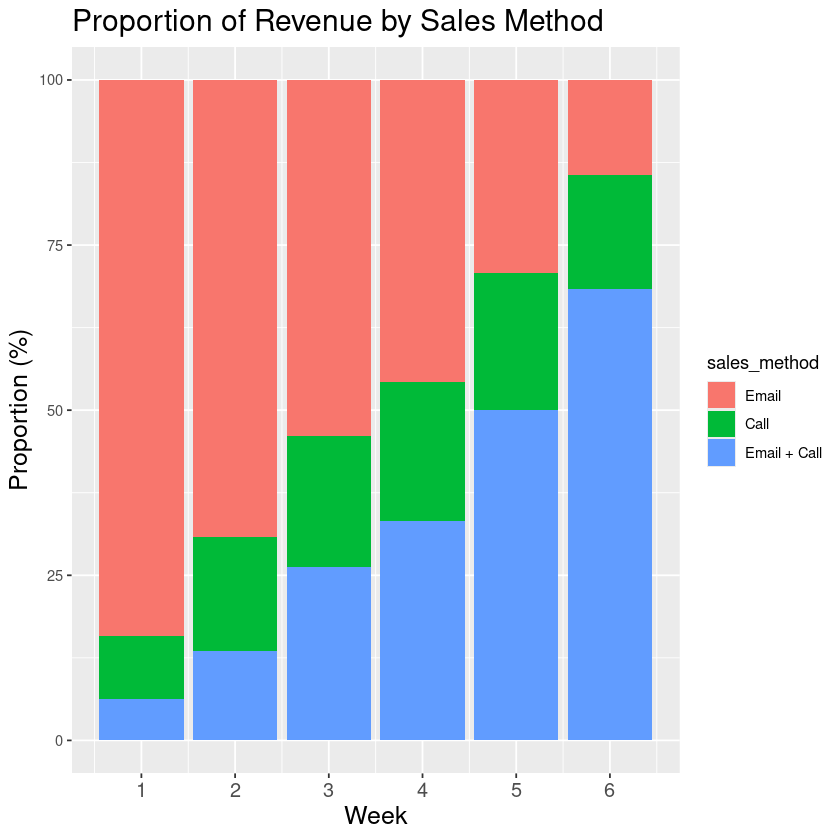

In [13]:
revenue_summ %>%
  filter(!is.na(week)) %>% 
  pivot_longer(cols = c(Call, Email, `Email + Call`), names_to = "sales_method", values_to = "revenue") %>%
  mutate(sales_method = factor(sales_method, levels = c("Email", "Call", "Email + Call"))) %>%
  ggplot(aes(x = week, y = revenue, fill = sales_method)) +
  geom_bar(stat = "identity") +
  scale_y_continuous(labels = label_comma()) +
  labs(title = "Revenue by week", y = "Revenue", x = "Week") +
  scale_x_continuous(breaks = c(1:6)) +
  theme(axis.text.x = element_text( size = 12), axis.title = element_text(size = 15), plot.title = element_text(size = 18))

revenue_summ_prop %>%
  filter(!is.na(week)) %>%
  pivot_longer(cols = c(Email, Call, `Email + Call`), names_to = "sales_method", values_to = "percentage") %>%
  mutate(sales_method = factor(sales_method, levels = c("Email", "Call", "Email + Call"))) %>%
  ggplot(aes(x = week, y = percentage, fill = sales_method)) +
  geom_bar(stat = "identity") +
  labs(title = "Proportion of Revenue by Sales Method", y = "Proportion (%)", x = "Week") +
  scale_x_continuous(breaks = c(1:6)) + 
  theme(axis.text.x = element_text( size = 12), axis.title = element_text(size = 15), plot.title = element_text(size = 18))

`summarise()` has grouped output by 'sales_method'. You can override using the
`.groups` argument.


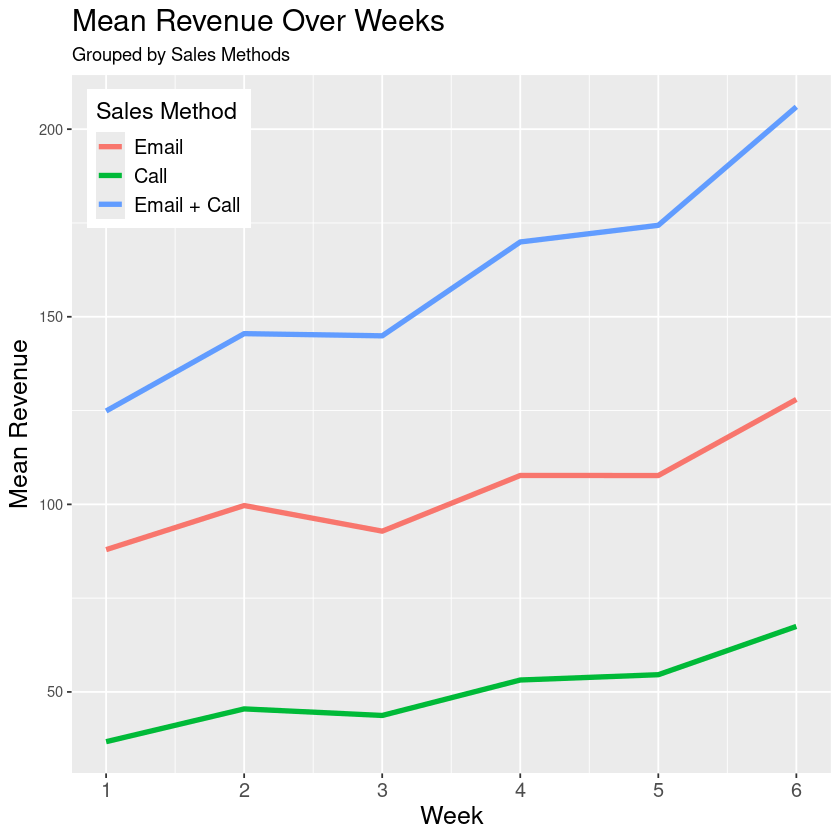

In [14]:
# Mean revenue over time by sales method 
data_val %>%
  group_by(sales_method, week) %>%
  summarize(revenue_mean = mean(revenue, na.rm = TRUE)) %>%
  ggplot(aes(x = week, y = revenue_mean, color = sales_method)) +
  geom_line(size = 1.5) + 
  labs(title = "Mean Revenue Over Weeks", subtitle = "Grouped by Sales Methods", x = "Week", y = "Mean Revenue", color = "Sales Method") + 
  scale_x_continuous(breaks = c(1:6)) +
  theme(plot.title = element_text(size = 18), legend.position = c(0.02, 0.98), legend.justification = c(0, 1),legend.title = element_text(size = 14), legend.text  = element_text(size = 12), axis.text.x = element_text( size = 12), axis.title = element_text(size = 15)) 

# 4. Ohter Differences between customers of each group

Then I compared three variables more to assess if there are differences between the groups. In all the cases assumption test were employed to evaluate the more accurate statistic test, in all cases the most appropiate was Kruskal Wallis test. 

1. The number of units sold by each method was statistically different between all of them. The Email + Call method generated the major number of products sold with a mean of of 12.23, at second place the Email method and the last place were the Call method with a mean of 9.73 and 9.51 respectively. This suggest that the customers contacted by Email + Call are more likely to buy more products per customer.
2. The years as a customer per methot were statistically different between Call method vs Email and Email + Call, but comparing Email vs Email + Call resulted in non-statistical significance. This information suggest that the differences in other variables comparing Email vs Email + Call are not related with the number of years as a customer.
3. Then, I compared the number of visits to our website in the last 6 months, and identified that the Email + Call method again was the one with highest visits. Suggesting that this method not just only increases the number of products sold by customer also increases the number of visits in our website.  

With this information we can conclude that the method Email + Call could be the most efficient of the three metrics considering all the variables evaluated. 

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,452.5523,1.450688e-191
,14997,NA,NA


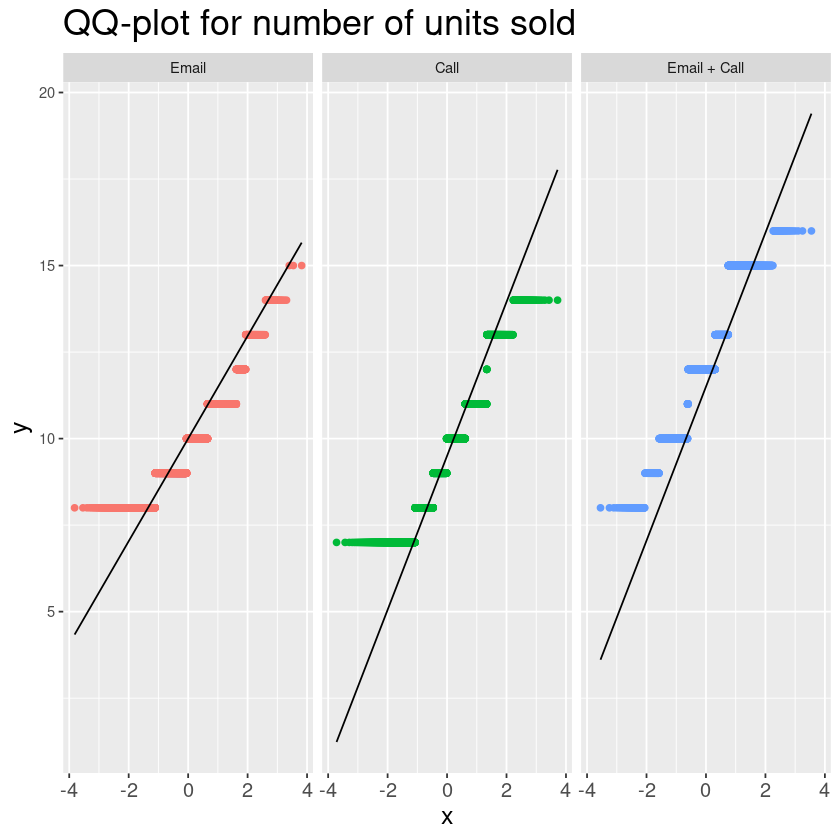

In [15]:
#Statistical asummptions
data_val %>%
ggplot(aes(sample = nb_sold)) +
  stat_qq(aes(color = sales_method)) +
  stat_qq_line() +
  labs(title = "QQ-plot for number of units sold") + 
  facet_wrap(~sales_method) + 
  theme(axis.text.x = element_text( size = 12), axis.title = element_text(size = 15), title = element_text(size = 18), legend.position = "none")

leveneTest(nb_sold ~ sales_method, data = data_val)


	Kruskal-Wallis rank sum test

data:  nb_sold by sales_method
Kruskal-Wallis chi-squared = 3301.4, df = 2, p-value < 2.2e-16



	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  data_val$nb_sold and data_val$sales_method 

             Email  Call  
Call         <2e-16 -     
Email + Call <2e-16 <2e-16

P value adjustment method: bonferroni 

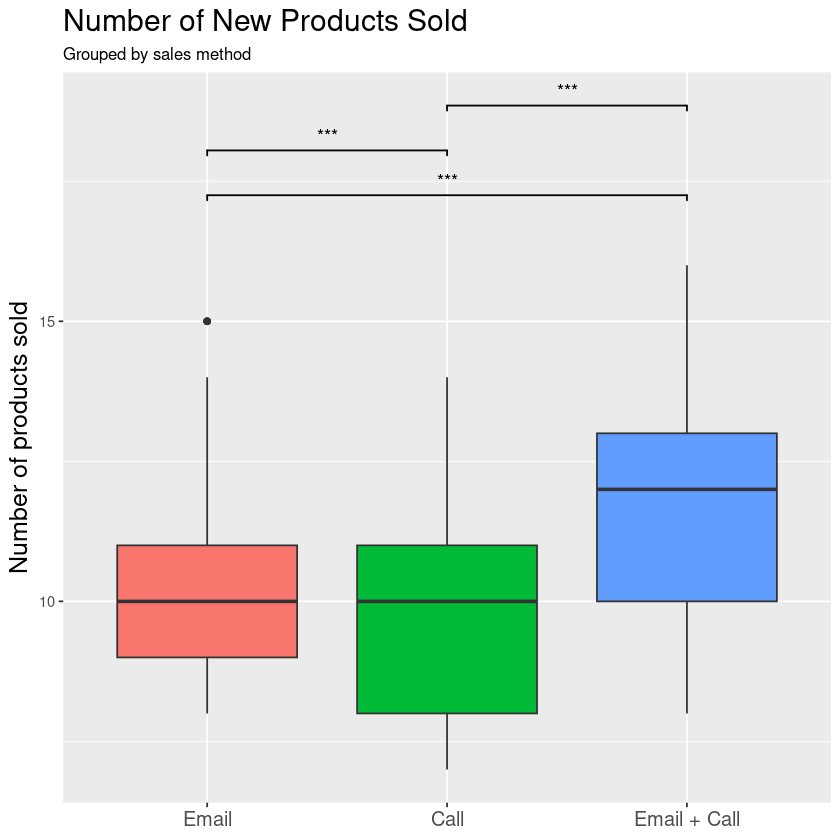

In [16]:
# nb_sold statistical test and graphing
kw_sold <- kruskal.test(nb_sold~sales_method, data = data_val)
kw_sold
posthoc_sold <- pairwise.wilcox.test(x = data_val$nb_sold,
                g = data_val$sales_method,
                p.adjust.method = "bonferroni")
posthoc_sold

max_sold <- max(data_val$nb_sold, na.rm = TRUE)
y_positions_sold <- seq(from = max_sold * 1.05,
                   by   = max_sold * 0.05,
                   length.out = length(comparisons))

pvals_sold <- na.omit(as.vector(posthoc_sold$p.value))
annotations_sold <- ifelse(pvals_sold < 0.001, "***",
               ifelse(pvals_sold < 0.01, "**",
               ifelse(pvals_sold < 0.05, "*", "ns")))

ggplot(data_val, aes(x = sales_method, y = nb_sold, fill = sales_method)) +
  geom_boxplot() +
  geom_signif(comparisons = comparisons,
              annotations = annotations_sold,
              y_position = y_positions_sold,
              tip_length = 0.01) + 
labs(title = "Number of New Products Sold", subtitle = "Grouped by sales method", x = NULL, y = "Number of products sold") +
theme(legend.position = "none", plot.title = element_text(size = 18), plot.subtitle = element_text(size =  10),  axis.text.x = element_text( size = 12), axis.title = element_text(size = 15))

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,5.991425,0.002506087
,14997,NA,NA


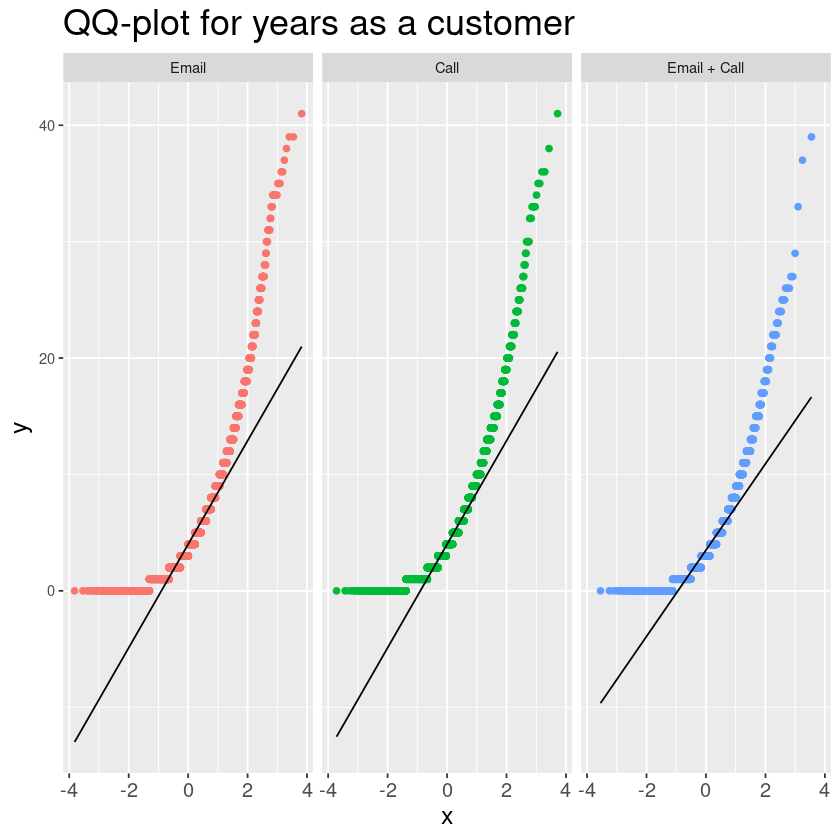

In [17]:
#Statistical asummptions
data_val %>%
ggplot(aes(sample = years_as_customer)) +
  stat_qq(aes(color = sales_method)) +
  stat_qq_line() +
  labs(title = "QQ-plot for years as a customer") + 
  facet_wrap(~sales_method) + 
  theme(axis.text.x = element_text( size = 12), axis.title = element_text(size = 15), title = element_text(size = 18), legend.position = "none")

leveneTest(years_as_customer ~ sales_method, data = data_val)


	Kruskal-Wallis rank sum test

data:  years_as_customer by sales_method
Kruskal-Wallis chi-squared = 42.479, df = 2, p-value = 5.968e-10



	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  data_val$years_as_customer and data_val$sales_method 

             Email   Call   
Call         0.066   -      
Email + Call 1.2e-06 3.1e-10

P value adjustment method: bonferroni 

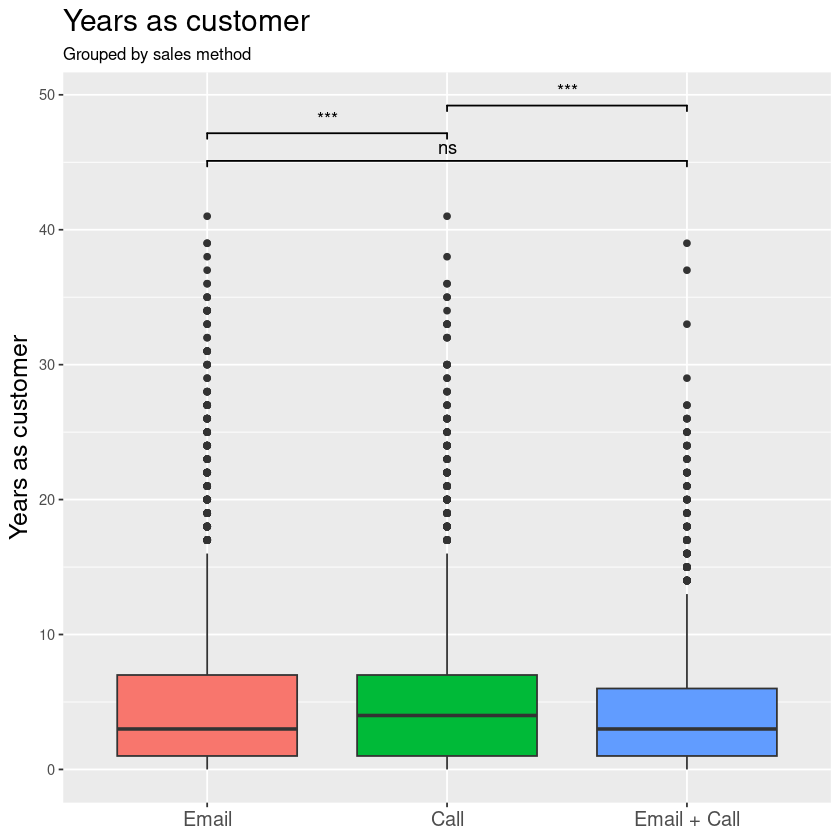

In [18]:
# years_as_customer statistical test and graphing
kw_years <- kruskal.test(years_as_customer~sales_method, data = data_val)
kw_years
posthoc_years <- pairwise.wilcox.test(x = data_val$years_as_customer,
                g = data_val$sales_method,
                p.adjust.method = "bonferroni")
posthoc_years

max_years <- max(data_val$years_as_customer, na.rm = TRUE)
y_positions_years <- seq(from = max_years * 1.05,
                   by   = max_years * 0.05,
                   length.out = length(comparisons))

pvals_years <- na.omit(as.vector(posthoc_years$p.value))
annotations_years <- ifelse(pvals_years < 0.001, "***",
               ifelse(pvals_years < 0.01, "**",
               ifelse(pvals_years < 0.05, "*", "ns")))

ggplot(data_val, aes(x = sales_method, y = years_as_customer, fill = sales_method)) +
  geom_boxplot() +
  geom_signif(comparisons = comparisons,
              annotations = annotations_years,
              y_position = y_positions_years,
              tip_length = 0.01) + 
labs(title = "Years as customer", subtitle = "Grouped by sales method", x = NULL, y = "Years as customer") +
theme(legend.position = "none", plot.title = element_text(size = 18), plot.subtitle = element_text(size =  10),  axis.text.x = element_text( size = 12), axis.title = element_text(size = 15))

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,33.84741,2.154435e-15
,14997,NA,NA


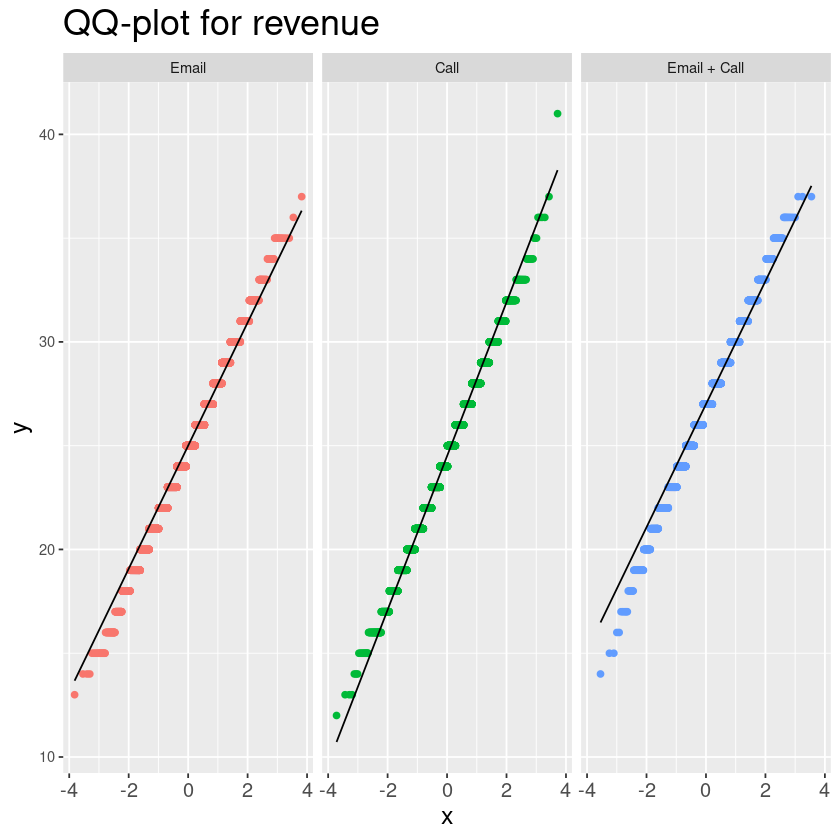

In [19]:
# Statistical assumptions
data_val %>%
ggplot(aes(sample = nb_site_visits)) +
  stat_qq(aes(color = sales_method)) +
  stat_qq_line() +
  labs(title = "QQ-plot for revenue") + 
  facet_wrap(~sales_method) + 
  theme(axis.text.x = element_text( size = 12), axis.title = element_text(size = 15), title = element_text(size = 18), legend.position = "none")

leveneTest(nb_site_visits ~ sales_method, data = data_val)


	Kruskal-Wallis rank sum test

data:  nb_site_visits by sales_method
Kruskal-Wallis chi-squared = 796.26, df = 2, p-value < 2.2e-16



	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  data_val$nb_site_visits and data_val$sales_method 

             Email   Call   
Call         2.9e-06 -      
Email + Call < 2e-16 < 2e-16

P value adjustment method: bonferroni 

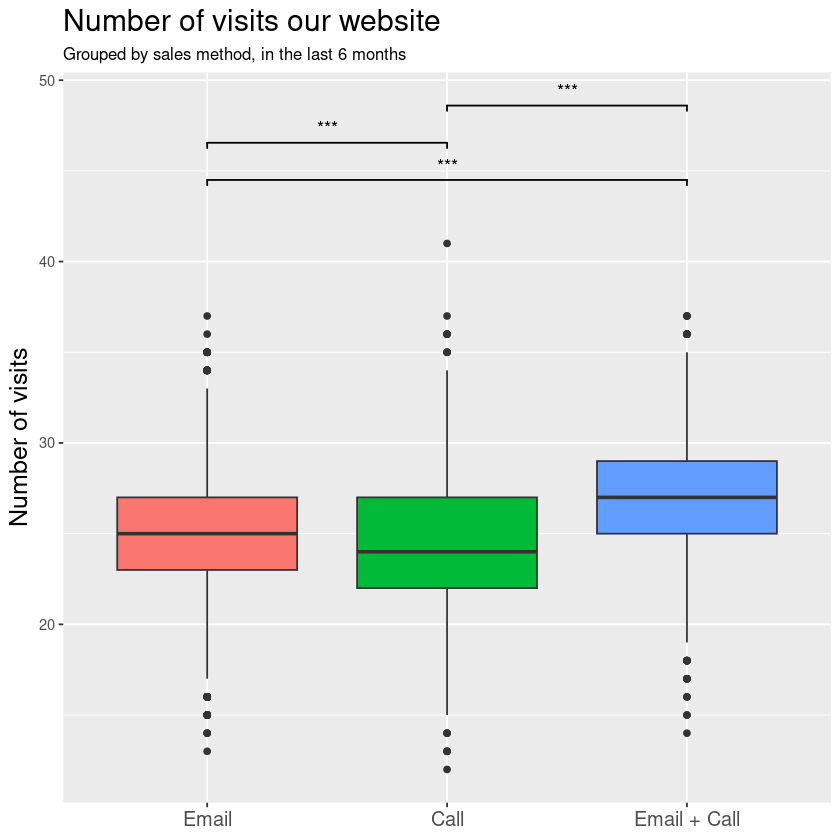

In [20]:
# nb_site_visits statistical test and graphing

kw_site <- kruskal.test(nb_site_visits~sales_method, data = data_val)
kw_site
posthoc_site <- pairwise.wilcox.test(x = data_val$nb_site_visits,
                g = data_val$sales_method,
                p.adjust.method = "bonferroni")
posthoc_site

max_site <- max(data_val$nb_site_visits, na.rm = TRUE)
y_positions_site <- seq(from = max_site * 1.05,
                   by   = max_site * 0.05,
                   length.out = length(comparisons))

pvals_site <- na.omit(as.vector(posthoc_site$p.value))
annotations_site <- ifelse(pvals_site < 0.001, "***",
               ifelse(pvals_site < 0.01, "**",
               ifelse(pvals_site < 0.05, "*", "ns")))

ggplot(data_val, aes(x = sales_method, y = nb_site_visits, fill = sales_method)) +
  geom_boxplot() +
  geom_signif(comparisons = comparisons,
              annotations = annotations_site,
              y_position = y_positions_site,
              tip_length = 0.01) + 
labs(title = "Number of visits our website", subtitle = "Grouped by sales method, in the last 6 months", x = NULL, y = "Number of visits") +
theme(legend.position = "none", plot.title = element_text(size = 18), plot.subtitle = element_text(size =  10),  axis.text.x = element_text( size = 12), axis.title = element_text(size = 15))

# Buissnes Metric: Adjusted Mean Revenue considering time and effort invested

Defining a buissnes metric that can be measurable by the team will help to follow-up the tendency of the revenue registered in this 6-week period strategy. So I defined a metric called "Adjusted Mean Revenue" (AMR) which consist in the mean revenue per customer, but adjusting this value by a difficult factor, this were determined by time consumed by the team depending on the strategy (5 for Email, 30 for Call and 10 for Email + Call). In this case the metrics were substancially different between the three groups. The AMR for the 6 week period were 16.093 with a standard deviation of 2.858. 

Considering this value as a baseline the main objective to monitor in the future will be mantain this value with a range of two times the standard deviation, this means this tendency will be considered if the AMR weekly is between 10.377 and 21.809. I suggest to implement this value as a metric to confirm the effectiviness of the Email + Call method, considering that the Email method in the first week of the strategy was by far the most effective in terms of revenue. 

In [21]:
diff_fac <- tibble(
  sales_method = c("Email", "Call", "Email + Call"),
  D = c(5, 30, 10))

adj_rev <- data_val %>%
  left_join(diff_fac, by = "sales_method") %>%
  group_by(week, sales_method) %>%
  summarise(adjusted_mean = mean(revenue) / first(D),
			.groups = "drop") %>%
  select(week, sales_method, adjusted_mean) %>%
  pivot_wider(names_from = sales_method, values_from = adjusted_mean)

adj_rev_tot <- data_val %>%
  left_join(diff_fac, by = "sales_method") %>%
  group_by(sales_method) %>%
  summarise(adjusted_mean =  mean(revenue) / first(D),
			.groups = "drop") %>%
  select(sales_method, adjusted_mean) %>%
  pivot_wider(names_from = sales_method, values_from = adjusted_mean)

bind_rows(adj_rev, adj_rev_tot)

week,Call,Email,Email + Call
<int>,<dbl>,<dbl>,<dbl>
1,1.224715,17.58574,12.48799
2,1.515945,19.93681,14.55017
3,1.457541,18.56985,14.49161
4,1.772648,21.53913,16.99397
5,1.819722,21.53689,17.43793
6,2.248925,25.59361,20.59621
NA,1.642924,19.37901,17.14774


In [22]:
adj_rev_mean <- data_val %>%
  left_join(diff_fac, by = "sales_method") %>%
  group_by(week, sales_method) %>%
  summarise(adjusted_mean =  mean(revenue) / first(D),
			.groups = "drop") %>%
  select(week, sales_method, adjusted_mean) %>%
 filter(sales_method == 'Email + Call') %>%
 summarize(mean = mean(adjusted_mean), 
		  stddev = sd(adjusted_mean))

adj_rev_mean

mean,stddev
<dbl>,<dbl>
16.09298,2.857984


# Conclusions and Recommendations

As a final summary: 
- The Email + Call method were the most stable with a healthy increase over the weeks.
- The Email method generated the highest revenue just in the first week, and then it were decreasing over the time.
- The Call method is the weakest of the three with the lowest revenue generated and the more time consuming versus the other methods. 
- The Adjusted Mean Revenue is a metric that can help the effectiviness of method implemented over time with a baseline of 16.093.
  